# 1 month freshwater budget test for panan-01

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_1_C = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-test-pan01_test_01-f7e0ea96/output091/*.ocean_month.nc'))
paths_2_C = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-test-pan01_test_01-f7e0ea96/output091/*.ocean_month_z.nc'))
paths_3_C = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-test-pan01_test_01-f7e0ea96/output091/*.ice_month.nc'))

paths_1_M = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-expt-3393fa55/output091/*.ocean_month.nc'))
paths_2_M = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-expt-3393fa55/output091/*.ocean_month_z.nc'))
paths_3_M = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-expt-3393fa55/output091/*.ice_month.nc'))

In [3]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['wfo','precip','fsitherm','fprec','precip','evap','lrunoff']].sel(yh=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['so']].sel(yh=lat_slice)
    return ds

def preprocess_3(ds):
    ds = ds[['net_melt']]
    return ds

data_1_C = xr.open_mfdataset(paths_1_C, preprocess = preprocess_1, chunks = 'auto')
data_2_C = xr.open_mfdataset(paths_2_C, preprocess = preprocess_2, chunks = 'auto')
data_3_C = xr.open_mfdataset(paths_3_C, preprocess = preprocess_3, chunks = 'auto')

data_1_M = xr.open_mfdataset(paths_1_M, preprocess = preprocess_1, chunks = 'auto')
data_2_M = xr.open_mfdataset(paths_2_M, preprocess = preprocess_2, chunks = 'auto')
data_3_M = xr.open_mfdataset(paths_3_M, preprocess = preprocess_3, chunks = 'auto')

In [4]:
data_1_C

<xarray.Dataset> Size: 40MB
Dimensions:   (time: 1, yh: 460, xh: 3600)
Coordinates:
  * time      (time) object 8B 2001-01-16 12:00:00
  * yh        (yh) float64 4kB -79.0 -78.95 -78.91 ... -59.14 -59.08 -59.03
  * xh        (xh) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Data variables:
    wfo       (time, yh, xh) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    precip    (time, yh, xh) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    fsitherm  (time, yh, xh) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    fprec     (time, yh, xh) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    evap      (time, yh, xh) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    lrunoff   (time, yh, xh) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             panan
    associated_files:  areacello: 20010101.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

In [5]:
# Sea surface salinity - maybe not needed
SSS_C = data_2_C.so.isel(z_l=0)

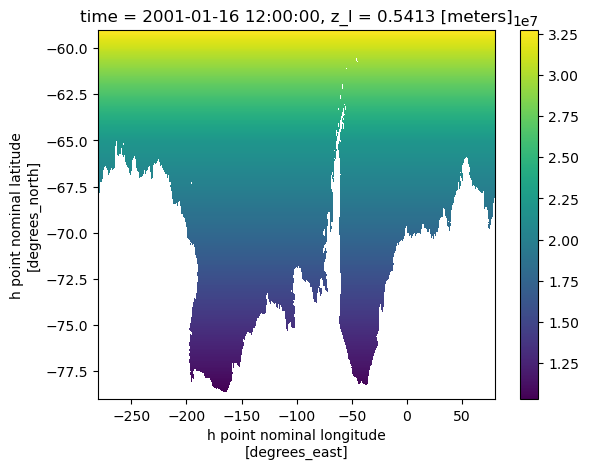

In [6]:
# Doing spatial average
area = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['areacello']
area_corr = area*(SSS_C*0 +1)
area_corr.plot()

In [7]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [8]:
depth = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['deptho']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom6_01')

The surface FW budget is given by:  
`wfo` = RIVER (runoff + calving) + `net_melt` + PME (precip - evap - net_melt) 

Need to confirm that `lrunoff` includes both runoff and calving fluxes from rivers. 

In [9]:
# Shelf only 
wfo_C = data_1_C.wfo.where(shelf_mask == 1)
lrunoff_C = data_1_C.lrunoff.where(shelf_mask == 1)
net_melt_C = data_3_C.net_melt.rename({'xT': 'xh', 'yT': 'yh'})
net_melt_C = net_melt_C.where(shelf_mask == 1)
fprec_C = data_1_C.fprec.where(shelf_mask == 1)
precip_C = data_1_C.precip.where(shelf_mask == 1)
evap_C = data_1_C.evap.where(shelf_mask == 1)

wfo_M = data_1_M.wfo.where(shelf_mask == 1)
lrunoff_M = data_1_M.lrunoff.where(shelf_mask == 1)
net_melt_M = data_3_M.net_melt.rename({'xT': 'xh', 'yT': 'yh'})
net_melt_M = net_melt_M.where(shelf_mask == 1)
fprec_M = data_1_M.fprec.where(shelf_mask == 1)
precip_M = data_1_M.precip.where(shelf_mask == 1)
evap_M = data_1_M.evap.where(shelf_mask == 1)

In [10]:
shelf_area = area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])

# Spatial average
wfo_ave_C = (area_corr * wfo_C).sum(['xh', 'yh']) / shelf_area
lrunoff_ave_C = (area_corr * lrunoff_C).sum(['xh', 'yh']) / shelf_area
net_melt_ave_C = (area_corr * net_melt_C).sum(['xh', 'yh']) / shelf_area
fprec_ave_C = (area_corr * fprec_C).sum(['xh', 'yh']) / shelf_area
precip_ave_C = (area_corr * precip_C).sum(['xh', 'yh']) / shelf_area
evap_ave_C = (area_corr * evap_C).sum(['xh', 'yh']) / shelf_area

wfo_ave_M = (area_corr * wfo_M).sum(['xh', 'yh']) / shelf_area
lrunoff_ave_M = (area_corr * lrunoff_M).sum(['xh', 'yh']) / shelf_area
net_melt_M = (area_corr * net_melt_M).sum(['xh', 'yh']) / shelf_area
fprec_ave_M = (area_corr * fprec_M).sum(['xh', 'yh']) / shelf_area
precip_ave_M = (area_corr * precip_M).sum(['xh', 'yh']) / shelf_area
evap_ave_M = (area_corr * evap_M).sum(['xh', 'yh']) / shelf_area

Breaking up the cells below because it was struggling to load all at once:

In [11]:
wfo_ave_C = wfo_ave_C.squeeze().load()

In [12]:
lrunoff_ave_C = lrunoff_ave_C.squeeze().load()
net_melt_ave_C = net_melt_ave_C.squeeze().load()

In [13]:
fprec_ave_C = fprec_ave_C.squeeze().load()
precip_ave_C = precip_ave_C.squeeze().load()
evap_ave_C = evap_ave_C.squeeze().load()

In [14]:
wfo_ave_M = wfo_ave_M.squeeze().load()
lrunoff_ave_M = lrunoff_ave_M.squeeze().load()
net_melt_ave_M = net_melt_M.squeeze().load()

In [15]:
fprec_ave_M = fprec_ave_M.squeeze().load()
precip_ave_M = precip_ave_M.squeeze().load()
evap_ave_M = evap_ave_M.squeeze().load()

In [16]:
# Term labels
terms = [
    "wfo",
    "lrunoff",
    "net_melt",
    "fprec",
    "precip",
    "evap",
    "budget",
]

# Control values
control = [
    wfo_ave_C.values,
    lrunoff_ave_C.values,
    net_melt_ave_C.values,
    fprec_ave_C.values,
    precip_ave_C.values,
    evap_ave_C.values,
    (lrunoff_ave_C + net_melt_ave_C + (precip_ave_C + evap_ave_C - net_melt_ave_C)).values,
]

# Meltwater values
melt = [
    wfo_ave_M.values,
    lrunoff_ave_M.values,
    net_melt_ave_M.values,
    fprec_ave_M.values,
    precip_ave_M.values,
    evap_ave_M.values,
    (lrunoff_ave_M + net_melt_ave_M + (precip_ave_M + evap_ave_M - net_melt_ave_M)).values,
]


In [20]:
## Saving these values to use in other analysis

# Save all arrays in one file
np.savez_compressed(
    "/g/data/x77/kc5856/analysis/access-panan-comparison/freshwater_budget_values.npz",
    wfo_C=wfo_ave_C.values,
    lrunoff_C=lrunoff_ave_C.values,
    net_melt_C=net_melt_ave_C.values,
    fprec_C=fprec_ave_C.values,
    precip_C=precip_ave_C.values,
    evap_C=evap_ave_C.values,
    budget_C=(lrunoff_ave_C + net_melt_ave_C + (precip_ave_C + evap_ave_C - net_melt_ave_C)).values,
    wfo_M=wfo_ave_M.values,
    lrunoff_M=lrunoff_ave_M.values,
    net_melt_M=net_melt_ave_M.values,
    fprec_M=fprec_ave_M.values,
    precip_M=precip_ave_M.values,
    evap_M=evap_ave_M.values,
    budget_M=(lrunoff_ave_M + net_melt_ave_M + (precip_ave_M + evap_ave_M - net_melt_ave_M)).values
)

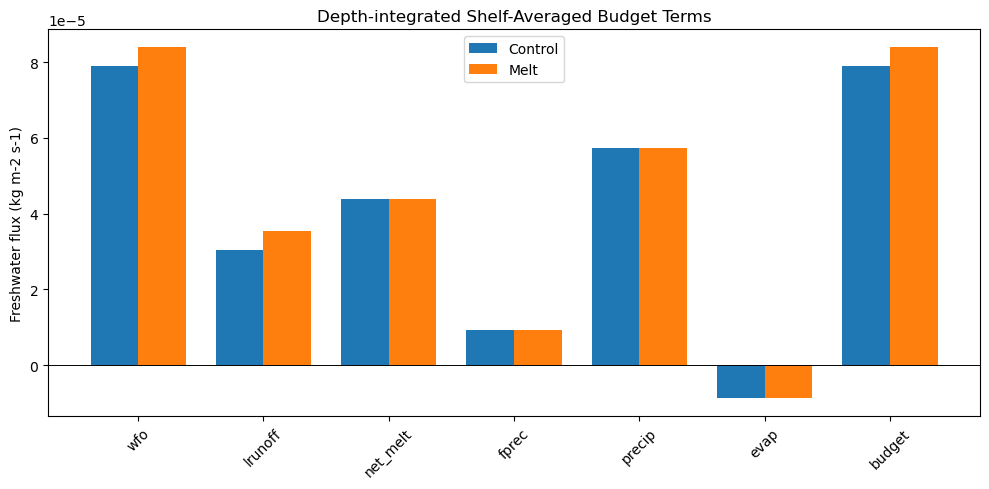

In [21]:
# Bar positions
x = np.arange(len(terms))
width = 0.38

# Create figure
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, control, width, label='Control')
plt.bar(x + width/2, melt, width, label='Melt')

plt.axhline(0, color='black', linewidth=0.7)
plt.ylabel("Freshwater flux (kg m-2 s-1)")
plt.xticks(x, terms, rotation=45)
plt.title("Depth-integrated Shelf-Averaged Budget Terms")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Checking closure: Control
budget_C = (lrunoff_ave_C + net_melt_ave_C + (precip_ave_C + evap_ave_C - net_melt_ave_C))
residual_C = wfo_ave_C - budget_C

# Checking closure: Melt
budget_M = (lrunoff_ave_M + net_melt_ave_M + (precip_ave_M + evap_ave_M - net_melt_ave_M))
residual_M = wfo_ave_M - budget_M

print("Control")
print(f"  wfo_ave_C = {float(wfo_ave_C.values):.6e}")
print(f"  budget_C        = {float(budget_C.values):.6e}")
print(f"  residual_C      = {float(residual_C.values):.6e}")

print("\nMelt")
print(f"  wfo_ave_M = {float(wfo_ave_M.values):.6e}")
print(f"  budget_M        = {float(budget_M.values):.6e}")
print(f"  residual_M      = {float(residual_M.values):.6e}")

Control
  wfo_ave_C = 7.884746e-05
  budget_C        = 7.884747e-05
  residual_C      = -7.275958e-12

Melt
  wfo_ave_M = 8.399413e-05
  budget_M        = 8.399412e-05
  residual_M      = 1.455192e-11


This is pretty closed.

In [28]:
# Control values
anomalies = [
    (wfo_ave_M - wfo_ave_C).values,
    (lrunoff_ave_M - lrunoff_ave_C).values,
    (net_melt_ave_M - net_melt_ave_C).values,
    (fprec_ave_M - fprec_ave_C).values,
    (precip_ave_M - precip_ave_C).values,
    (evap_ave_M - evap_ave_C).values,
    (budget_M - budget_C).values,
]

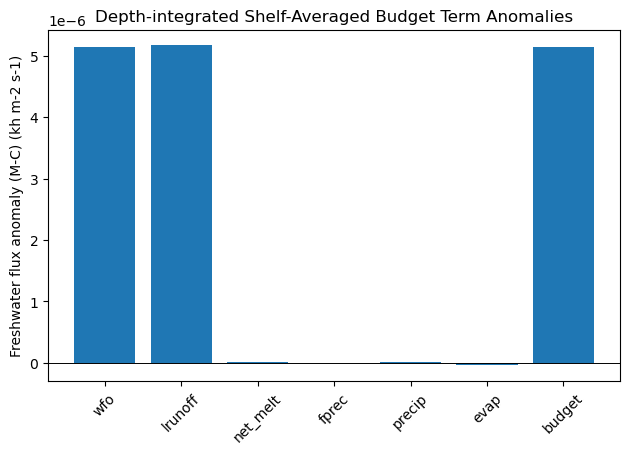

In [30]:
# Create figure
plt.figure()
plt.bar(terms, anomalies)

plt.ylabel("Freshwater flux anomaly (M-C) (kh m-2 s-1)")
plt.axhline(0, color='black', linewidth=0.7)
plt.title("Depth-integrated Shelf-Averaged Budget Term Anomalies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Anomaly is dominated by runoff perturbation, as expected.